In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import BarycentricInterpolator, CubicSpline

# a)

In [27]:
def f1(x):
    return 1 / (1 + 25 * x**2)

In [28]:
n = 12
n_dense = n * 10

In [29]:
x_eq = np.linspace(-1, 1, n)
y_eq = f1(x_eq)
x_dense_eq = np.linspace(-1, 1, n_dense)

In [30]:
j = np.arange(1, n + 1)
theta_cheb = (2 * j - 1) / (2 * n) * np.pi
x_cheb = np.cos(theta_cheb)
y_cheb = f1(x_cheb)

In [31]:
theta_dense = np.linspace(0, np.pi, n_dense)
x_dense_cheb = np.sort(np.cos(theta_dense))

In [32]:
poly_eq = BarycentricInterpolator(x_eq, y_eq)
y_poly_eq = poly_eq(x_dense_eq)

In [33]:
cs_eq = CubicSpline(x_eq, y_eq)
y_cs_eq = cs_eq(x_dense_eq)

In [34]:
poly_cheb = BarycentricInterpolator(x_cheb, y_cheb)
y_poly_cheb = poly_cheb(x_dense_cheb)

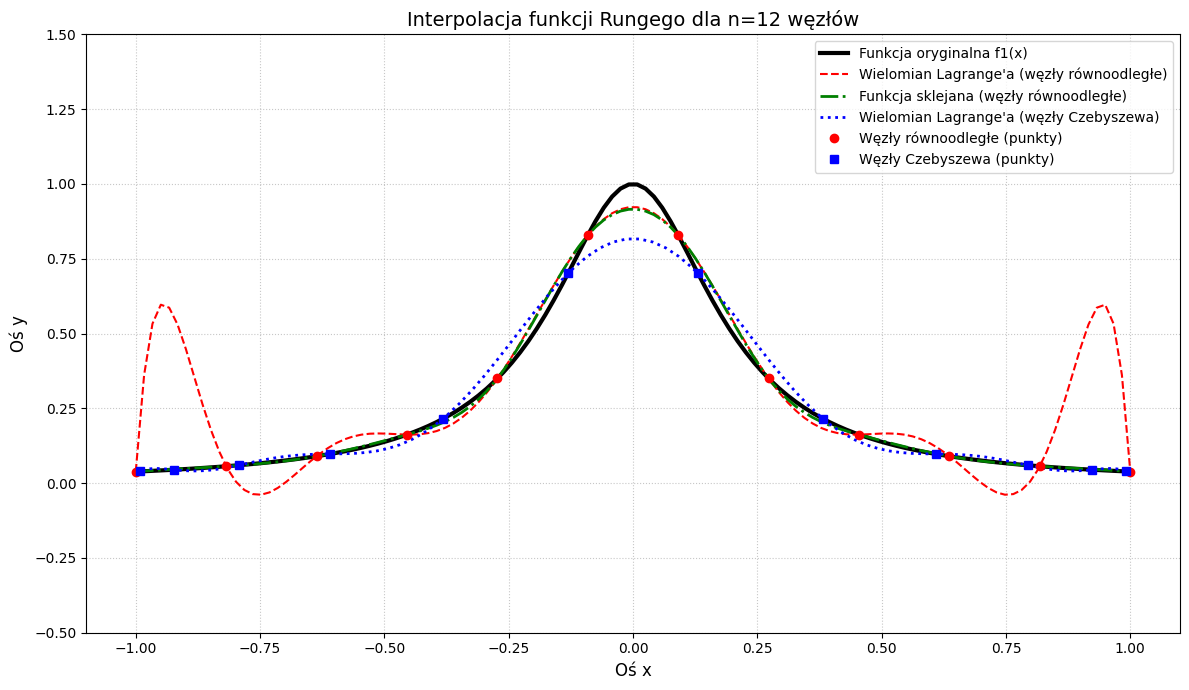

In [35]:
plt.figure(figsize=(12, 7))

plt.plot(x_dense_eq, f1(x_dense_eq), 'k-', linewidth=3, label='Funkcja oryginalna f1(x)')
plt.plot(x_dense_eq, y_poly_eq, 'r--', linewidth=1.5, label='Wielomian Lagrange\'a (węzły równoodległe)')
plt.plot(x_dense_eq, y_cs_eq, 'g-.', linewidth=2, label='Funkcja sklejana (węzły równoodległe)')
plt.plot(x_dense_cheb, y_poly_cheb, 'b:', linewidth=2, label='Wielomian Lagrange\'a (węzły Czebyszewa)')

plt.plot(x_eq, y_eq, 'ro', markersize=6, label='Węzły równoodległe (punkty)')
plt.plot(x_cheb, y_cheb, 'bs', markersize=6, label='Węzły Czebyszewa (punkty)')

plt.ylim(-0.5, 1.5)

plt.title(f'Interpolacja funkcji Rungego dla n={n} węzłów', fontsize=14)
plt.xlabel('Oś x', fontsize=12)
plt.ylabel('Oś y', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

# b)

In [36]:
def f2(x):
    return np.exp(np.cos(x))

In [37]:
n_vals = np.arange(4, 51)
num_eval = 500

In [38]:

np.random.seed(42) 
x_eval_f1 = np.random.uniform(-1, 1, num_eval)
x_eval_f2 = np.random.uniform(0, 2*np.pi, num_eval)

In [39]:
y_true_f1 = f1(x_eval_f1)
y_true_f2 = f2(x_eval_f2)

In [40]:
err_f1 = {'eq': [], 'spline': [], 'cheb': []}
err_f2 = {'eq': [], 'spline': [], 'cheb': []}

for n in n_vals:
    x_eq_f1 = np.linspace(-1, 1, n)
    j = np.arange(1, n + 1)
    x_cheb_f1 = np.cos((2 * j - 1) / (2 * n) * np.pi)
    
    x_eq_f2 = np.linspace(0, 2*np.pi, n)
    x_cheb_f2 = np.pi * (x_cheb_f1 + 1) 
    
    poly_eq_f1 = BarycentricInterpolator(x_eq_f1, f1(x_eq_f1))
    cs_f1 = CubicSpline(x_eq_f1, f1(x_eq_f1))
    poly_cheb_f1 = BarycentricInterpolator(x_cheb_f1, f1(x_cheb_f1))
    
    err_f1['eq'].append(np.linalg.norm(y_true_f1 - poly_eq_f1(x_eval_f1)))
    err_f1['spline'].append(np.linalg.norm(y_true_f1 - cs_f1(x_eval_f1)))
    err_f1['cheb'].append(np.linalg.norm(y_true_f1 - poly_cheb_f1(x_eval_f1)))

    poly_eq_f2 = BarycentricInterpolator(x_eq_f2, f2(x_eq_f2))
    cs_f2 = CubicSpline(x_eq_f2, f2(x_eq_f2))
    poly_cheb_f2 = BarycentricInterpolator(x_cheb_f2, f2(x_cheb_f2))
    
    err_f2['eq'].append(np.linalg.norm(y_true_f2 - poly_eq_f2(x_eval_f2)))
    err_f2['spline'].append(np.linalg.norm(y_true_f2 - cs_f2(x_eval_f2)))
    err_f2['cheb'].append(np.linalg.norm(y_true_f2 - poly_cheb_f2(x_eval_f2)))

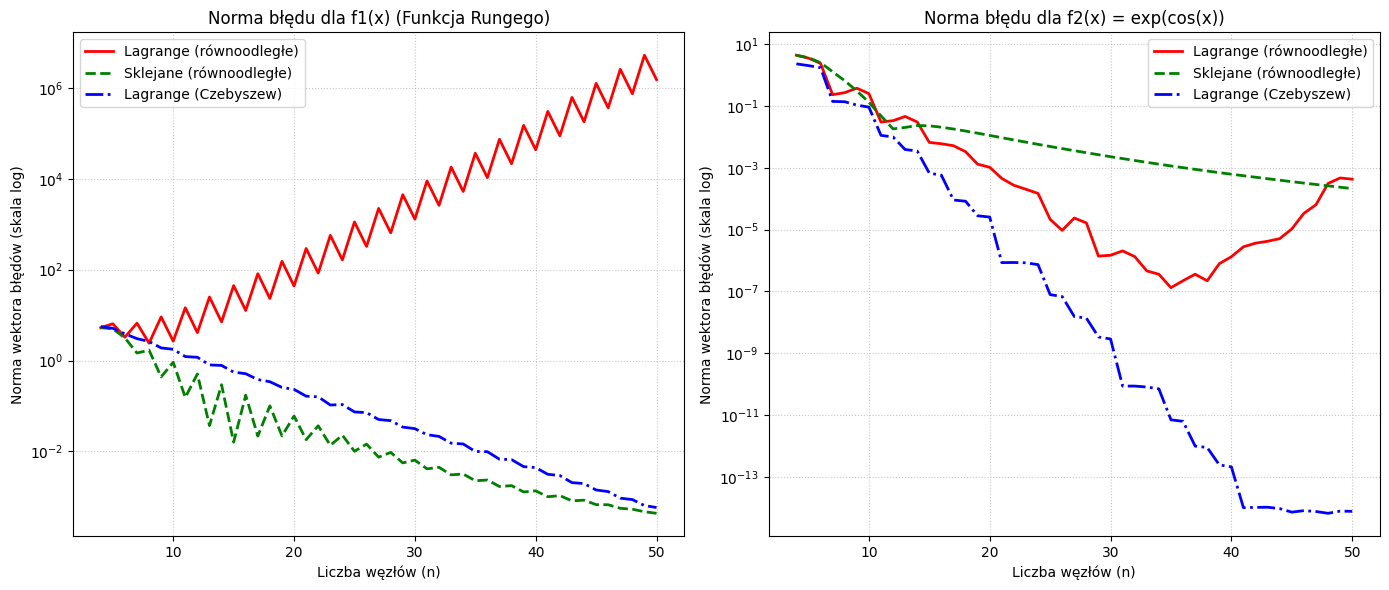

In [41]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.semilogy(n_vals, err_f1['eq'], 'r-', linewidth=2, label="Lagrange (równoodległe)")
ax1.semilogy(n_vals, err_f1['spline'], 'g--', linewidth=2, label="Sklejane (równoodległe)")
ax1.semilogy(n_vals, err_f1['cheb'], 'b-.', linewidth=2, label="Lagrange (Czebyszew)")
ax1.set_title("Norma błędu dla f1(x) (Funkcja Rungego)")
ax1.set_xlabel("Liczba węzłów (n)")
ax1.set_ylabel("Norma wektora błędów (skala log)")
ax1.legend()
ax1.grid(True, which="both", ls=":", alpha=0.7)

ax2.semilogy(n_vals, err_f2['eq'], 'r-', linewidth=2, label="Lagrange (równoodległe)")
ax2.semilogy(n_vals, err_f2['spline'], 'g--', linewidth=2, label="Sklejane (równoodległe)")
ax2.semilogy(n_vals, err_f2['cheb'], 'b-.', linewidth=2, label="Lagrange (Czebyszew)")
ax2.set_title("Norma błędu dla f2(x) = exp(cos(x))")
ax2.set_xlabel("Liczba węzłów (n)")
ax2.set_ylabel("Norma wektora błędów (skala log)")
ax2.legend()
ax2.grid(True, which="both", ls=":", alpha=0.7)

plt.tight_layout()
plt.show()